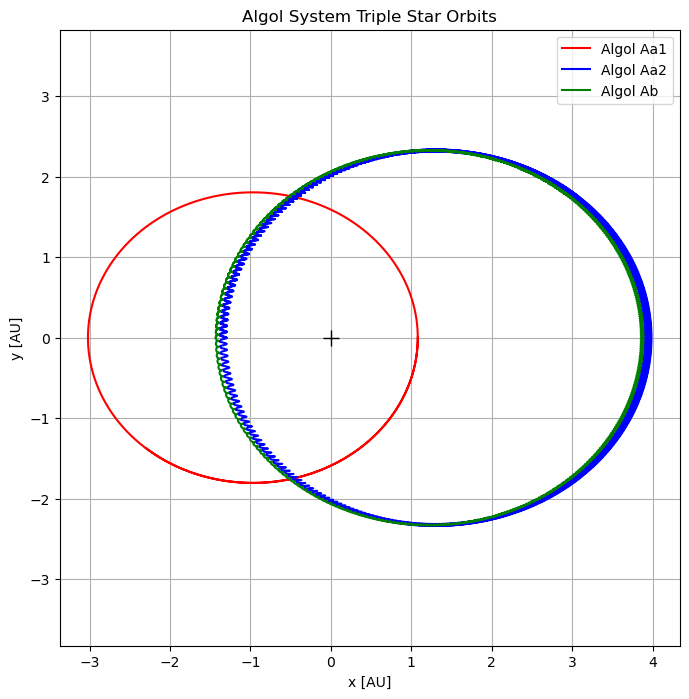

In [14]:
#triple star system Beta Persei (Algo Aa1, Aa2, Ab)

import numpy as np                            
import matplotlib.pyplot as plt             
from scipy.constants import G, au, day       
from astropy.constants import M_sun          
from scipy.integrate import solve_ivp        

# Masses of Stars 
M1 = 3.17 * M_sun.value  # Mass of Algol Aa1.
M2 = 0.70 * M_sun.value  # Mass of Algol Aa2.
M3 = 1.76 * M_sun.value  # Mass of Algol AAb.


# INNER ORBIT (Aa1 and Aa2)
T12 = 680.2 * day   # Orbital period of the inner binary (in seconds).
e12 = 0             # Eccentricity of the inner orbit (0 indicates a circular orbit).


# OUTER ORBIT PARAMETERS (Inner binary center-of-mass with Algol Ab)
T = 680.2 * day     # Orbital period of the outer orbit (in seconds).
e = 0.227           # Eccentricity of the outer orbit.


# Calculate semi-major axes using Kepler's third law.
# a12: semi-major axis of the inner binary.
# a: semi-major axis of the outer orbit (the full triple system).
a12 = (T12 / (2 * np.pi)) ** (2 / 3) * (G * (M1 + M2)) ** (1 / 3)
a = (T / (2 * np.pi)) ** (2 / 3) * (G * (M1 + M2 + M3)) ** (1 / 3)


# INITIAL CONDITIONS


# Set initial positions for the inner binary (relative to their center-of-mass).
x1 = d12 * M2 / M12                # Position for Algol Aa1.
y1 = 0
x2 = -d12 * M1 / M12               # Position for Algol Aa2.(Negative sign indicates direction.)
y2 = 0

# Inner binary initial velocities (for a circular orbit, velocity is perpendicular to the radius).
vx1 = 0
vx2 = 0
vy1 = -v12 * M2 / M12              #velocity for Algol Aa1 (Negative sign indicates direction).
vy2 = v12 * M1 / M12               #velocity for Algol Aa2 


# Calculate parameters for the inner orbit.
M12 = M1 + M2                      # Total mass of the inner binary.
d12 = a12 * (1 - e12)              # Periastron distance of the inner binary.
v12 = np.sqrt(G * M12 * (2 / d12 - 1 / a12))  # Orbital speed from the vis-viva equation.(refer to internet about this equation)

# Calculate parameters for the outer orbit.
d = a * (1 - e)                    # Periastron distance of the outer orbit.
v = np.sqrt(G * (M12 + M3) * (2 / d - 1 / a))  # Orbital speed for the outer orbit.


# Adjust the inner binary positions to account for the outer orbit's center-of-mass motion.
shift = d * M3 / (M12 + M3)
x1 += shift
x2 += shift


# Set the initial position for the third star (Algol Ab) in the outer orbit.
x3 = -d * M12 / (M12 + M3)
y3 = 0
# Set the initial velocity for the third star.
vx3 = 0
vy3 = v * M12 / (M12 + M3)

# Adjust the inner binary velocities to account for the outer orbital motion.
vy1 -= v * M3 / (M12 + M3)
vy2 -= v * M3 / (M12 + M3)


# Combine all initial conditions into a single state vector.
# The state vector is: [x1, y1, x2, y2, x3, y3, vx1, vy1, vx2, vy2, vx3, vy3]
state0 = np.array([x1, y1, x2, y2, x3, y3, vx1, vy1, vx2, vy2, vx3, vy3])


# DEFINE THE DERIVATION FUNCTION
def state_derv(t, state):
    """
    Compute the time derivatives of the state vector for the three-body system.
    
    The state vector is defined as:
    [x1, y1, x2, y2, x3, y3, vx1, vy1, vx2, vy2, vx3, vy3]
    """
    # Calculate mass-dependent gravitational constants for each pair.
    alpha = G * M1 * M2
    beta = G * M1 * M3
    gamma = G * M2 * M3
    
    # Compute differences in positions between bodies.
    delta12_x = state[2] - state[0]  # x2 - x1.
    delta12_y = state[3] - state[1]  # y2 - y1.
    delta13_x = state[4] - state[0]  # x3 - x1.
    delta13_y = state[5] - state[1]  # y3 - y1.
    delta23_x = state[4] - state[2]  # x3 - x2.
    delta23_y = state[5] - state[3]  # y3 - y2.
    
    # Calculate force components using Newton's law of gravitation.
    # The denominator (distance^3) converts scalar force into a vector.
    F12x = alpha * delta12_x / (delta12_x**2 + delta12_y**2) ** (3/2)
    F12y = alpha * delta12_y / (delta12_x**2 + delta12_y**2) ** (3/2)
    F13x = beta * delta13_x / (delta13_x**2 + delta13_y**2) ** (3/2)
    F13y = beta * delta13_y / (delta13_x**2 + delta13_y**2) ** (3/2)
    F23x = gamma * delta23_x / (delta23_x**2 + delta23_y**2) ** (3/2)
    F23y = gamma * delta23_y / (delta23_x**2 + delta23_y**2) ** (3/2)
    
    # Compute the derivatives: first positions (which equal the velocities),
    # then accelerations (net force divided by the respective mass).
    return np.array([
        state[6], state[7],              # dx1/dt = vx1, dy1/dt = vy1.
        state[8], state[9],              # dx2/dt = vx2, dy2/dt = vy2.
        state[10], state[11],            # dx3/dt = vx3, dy3/dt = vy3.
        (F12x + F13x) / M1, (F12y + F13y) / M1,  # Accelerations for star 1.
        (-F12x + F23x) / M2, (-F12y + F23y) / M2,  # Accelerations for star 2.
        (-F13x - F23x) / M3, (-F13y - F23y) / M3 ])  # Accelerations for star 3.
    


# INTEGRATION PARAMETERS AND SOLUTION

T_total = 3 * T  # Set the total integration time (e.g., 3 outer orbital periods)
# Create x axis.
n_steps = 10000
t_eval = np.linspace(0, T_total, n_steps)

# Solve the ODE system using RK45 with high tolerances using scipy pacakage.
sol = solve_ivp(state_derv, [0, T_total], state0, t_eval=t_eval, rtol=1e-9, atol=1e-12)

# Extract the positions (convert from meters to AU for plotting).
x1_vals = sol.y[0] / au
y1_vals = sol.y[1] / au
x2_vals = sol.y[2] / au
y2_vals = sol.y[3] / au
x3_vals = sol.y[4] / au
y3_vals = sol.y[5] / au


# PLOTTING
plt.figure(figsize=(8, 8))                     
plt.plot([0], [0], '+k', markersize=12)      
plt.plot(x1_vals, y1_vals, 'r-', label="Algol Aa1")  
plt.plot(x2_vals, y2_vals, 'b-', label="Algol Aa2")  
plt.plot(x3_vals, y3_vals, 'g-', label="Algol Ab")    
plt.xlabel("x [AU]")                          
plt.ylabel("y [AU]")                           
plt.title("Algol System Triple Star Orbits")  
plt.legend()                                   
plt.grid(True)                               
plt.axis("equal")                            
plt.show()                                    